# Anomaly Detection
## “How do countries behave over time inside each cluster?”

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/anomaly")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


PosixPath('../worldbank_tableau_project/outputs/anomaly')

In [7]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [8]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [9]:
pca_df = pd.read_csv("../worldbank_tableau_project/outputs/clustering/pca_clusters.csv")

In [10]:
pca_df.head()

,country_name,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Cluster,region
0,Algeria,-0.837744,0.597726,-1.528005,-0.095624,-0.702257,-0.137335,0.141079,-0.659615,-0.308707,3,North Africa
1,Bahrain,1.900227,0.039329,-0.340081,-0.170821,-0.063872,-0.129657,-0.074608,0.345520,0.495636,1,GCC
2,"Egypt, Arab Rep.",-1.799994,-0.372545,-0.168229,2.279048,-0.561394,1.120786,-0.216897,0.106215,0.285203,2,North Africa
3,"Iran, Islamic Rep.",-1.443357,-0.298715,0.983355,2.304485,-0.561044,-0.073520,0.075837,-0.660563,0.011879,2,Other
4,Iraq,-2.375472,0.039955,0.165216,-0.658568,1.856444,1.002499,-0.838879,0.447198,-0.060468,2,Other


In [11]:
pca_df.columns

Index(['country_name', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8',
       'PC9', 'Cluster', 'region'],
      dtype='object')

In [12]:
anomaly_df = pca_df[[
    "country_name",
    "region",
    "Cluster",
    "PC1", "PC2", "PC3"
]].copy()

anomaly_df.set_index("country_name", inplace=True)
anomaly_df.head()


,region,Cluster,PC1,PC2,PC3
country_name,,,,,
Algeria,North Africa,3,-0.837744,0.597726,-1.528005
Bahrain,GCC,1,1.900227,0.039329,-0.340081
"Egypt, Arab Rep.",North Africa,2,-1.799994,-0.372545,-0.168229
"Iran, Islamic Rep.",Other,2,-1.443357,-0.298715,0.983355
Iraq,Other,2,-2.375472,0.039955,0.165216


In [13]:
X_anom = anomaly_df[["PC1", "PC2", "PC3"]].values


In [14]:
iso = IsolationForest(
    contamination=0.15,   # ~15% of countries flagged as anomalies (tune later)
    random_state=42
)

iso_labels = iso.fit_predict(X_anom)         # -1 = outlier, 1 = inlier
iso_raw_scores = iso.decision_function(X_anom)  # higher = more "normal"


In [15]:
anomaly_df["iso_raw_score"] = iso_raw_scores
anomaly_df["iso_anomaly_score"] = -iso_raw_scores   # flip: higher = more anomalous
anomaly_df["iso_label"] = np.where(iso_labels == -1, 1, 0)  # 1 = anomaly, 0 = normal

anomaly_df.sort_values("iso_anomaly_score", ascending=False)


,region,Cluster,PC1,PC2,PC3,iso_raw_score,iso_anomaly_score,iso_label
country_name,,,,,,,,
Lebanon,Levant,0,-0.729063,3.136066,2.908014,-0.074709,0.074709,1
West Bank and Gaza,Levant,4,-0.624159,-3.355717,1.521529,-0.048471,0.048471,1
"Yemen, Rep.",Other,2,-2.902448,-1.372818,-0.466374,-0.007338,0.007338,1
Morocco,North Africa,3,-1.118704,1.106070,-2.427395,0.006004,-0.006004,0
Qatar,GCC,1,3.944395,-0.583992,0.376699,0.010008,-0.010008,0
Libya,North Africa,3,-0.158361,1.878770,0.239968,0.069342,-0.069342,0
Tunisia,North Africa,3,0.200594,0.844160,-1.104354,0.090650,-0.090650,0
Algeria,North Africa,3,-0.837744,0.597726,-1.528005,0.098459,-0.098459,0
United Arab Emirates,GCC,1,2.751629,0.145465,-0.283745,0.100243,-0.100243,0


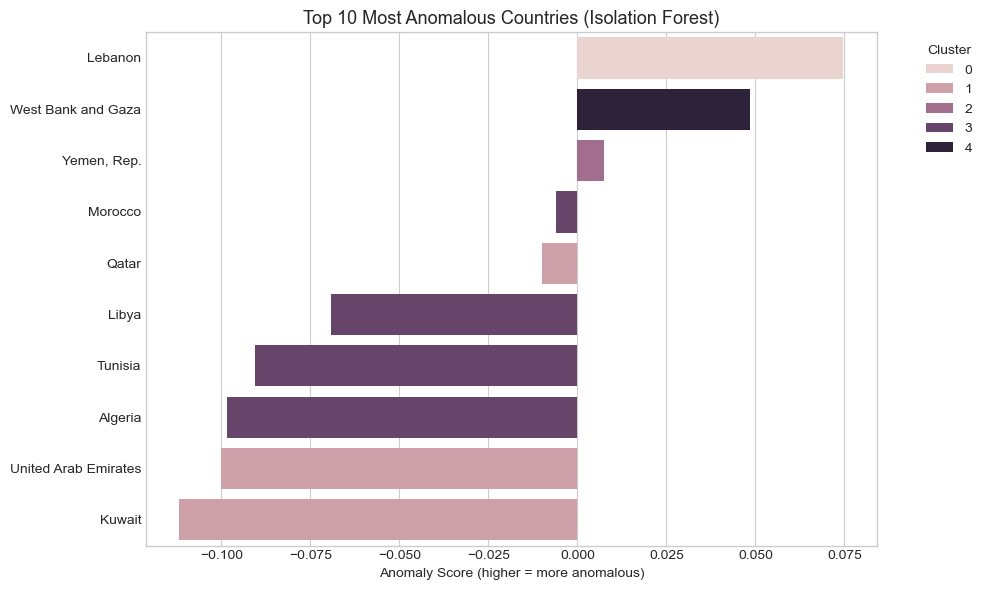

In [16]:
top_n = 10

top_anomalies = (
    anomaly_df
    .sort_values("iso_anomaly_score", ascending=False)
    .head(top_n)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_anomalies,
    x="iso_anomaly_score",
    y="country_name",
    hue="Cluster",
    dodge=False
)
plt.xlabel("Anomaly Score (higher = more anomalous)")
plt.ylabel("")
plt.title(f"Top {top_n} Most Anomalous Countries (Isolation Forest)", fontsize=13)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "iso_top_anomalies_bar.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
anomaly_df.reset_index().to_csv(
    OUTPUT_DIR / "country_anomaly_scores.csv",
    index=False
)


In [20]:
anomaly_df.columns

Index(['region', 'Cluster', 'PC1', 'PC2', 'PC3', 'iso_raw_score',
       'iso_anomaly_score', 'iso_label'],
      dtype='object')

### 1. Cluster-Faceted Anomaly Bar Charts

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_30979/1330217559.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


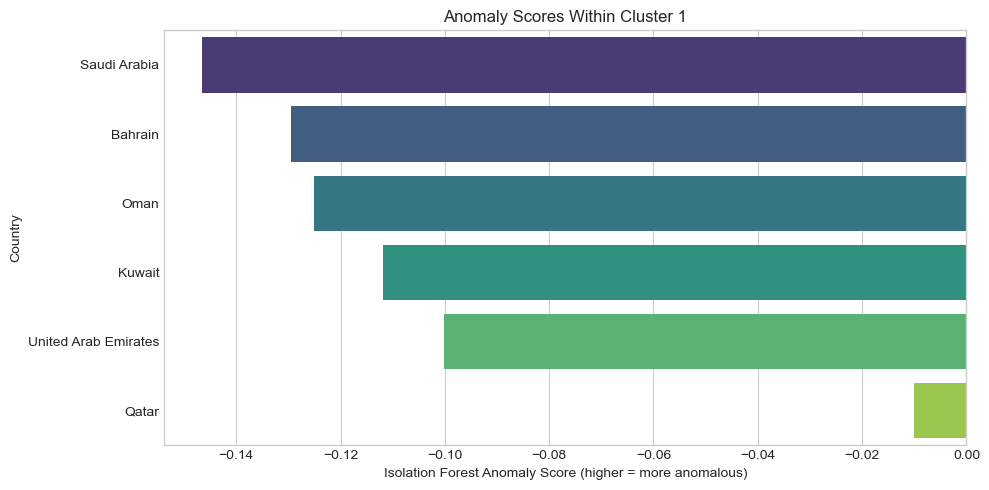

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_30979/1330217559.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


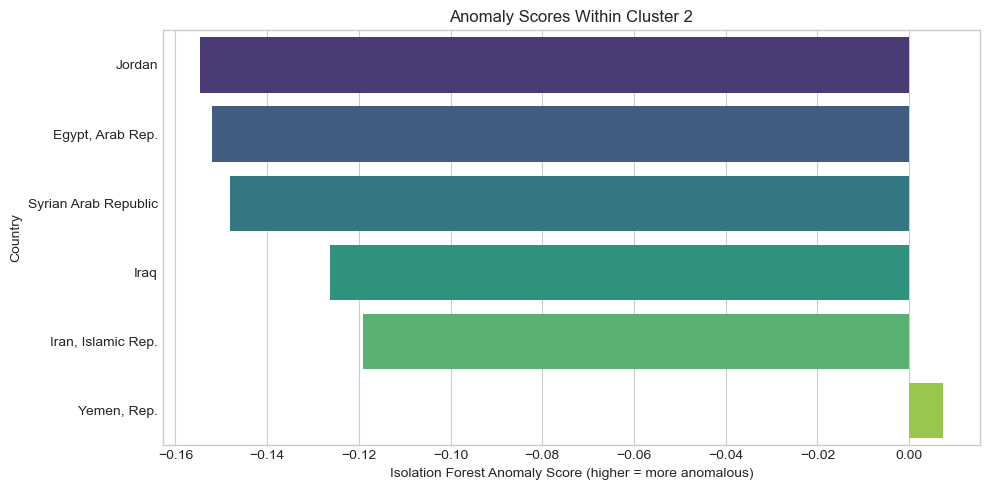

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_30979/1330217559.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


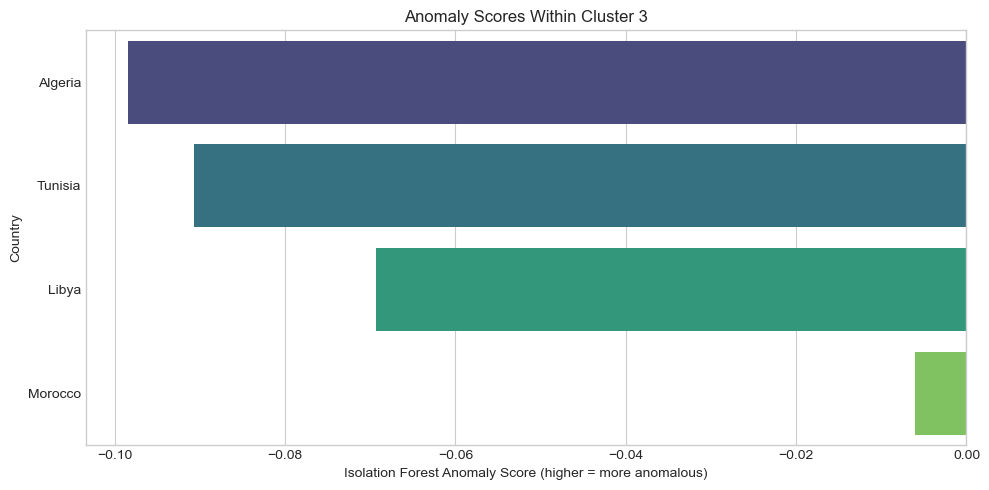

Saved: cluster anomaly bar charts for clusters 1, 2, 3


In [21]:

# Unique clusters except singletons (0 = Lebanon, 4 = WBG)
clusters_to_plot = [1, 2, 3]  

for cluster_id in clusters_to_plot:
    df_cluster = anomaly_df[anomaly_df["Cluster"] == cluster_id].copy()
    df_cluster = df_cluster.sort_values("iso_anomaly_score", ascending=True)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_cluster,
        x="iso_anomaly_score",
        y="country_name",
        palette="viridis"
    )
    plt.title(f"Anomaly Scores Within Cluster {cluster_id}")
    plt.xlabel("Isolation Forest Anomaly Score (higher = more anomalous)")
    plt.ylabel("Country")

    # Save plot
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}cluster_{cluster_id}_anomaly_bars.png", dpi=300)
    plt.show()

print("Saved: cluster anomaly bar charts for clusters 1, 2, 3")


### PC1 vs. Anomaly Score Scatter Plot

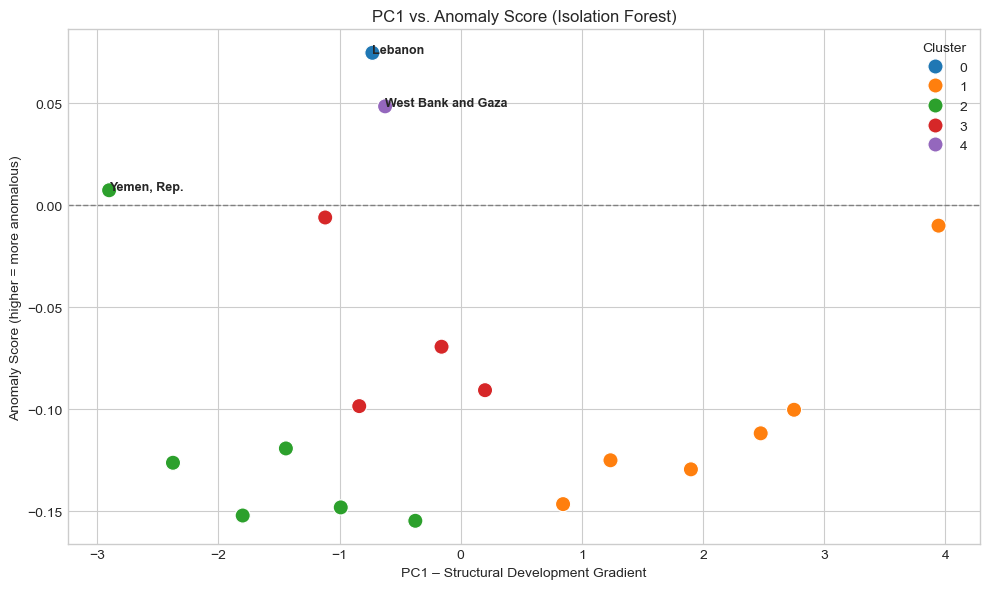

Saved: PC1 vs anomaly scatter plot


In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=anomaly_df,
    x="PC1",
    y="iso_anomaly_score",
    hue="Cluster",
    palette="tab10",
    s=120
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("PC1 vs. Anomaly Score (Isolation Forest)")
plt.xlabel("PC1 – Structural Development Gradient")
plt.ylabel("Anomaly Score (higher = more anomalous)")

# Annotate extreme outliers
for country, x, y in zip(anomaly_df.index, anomaly_df["PC1"], anomaly_df["iso_anomaly_score"]):
    if y > 0:  # Only annotate positive anomalies
        plt.text(x, y, country, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}pc1_vs_anomaly_scatter.png", dpi=300)
plt.show()

print("Saved: PC1 vs anomaly scatter plot")
